# Retrieval Evaluation

## Goal
Measure how well a retrieval system finds relevant documents for a query.
Good retrieval = better generation = less hallucination.

## Metrics
- Precision@K: of the top K retrieved chunks, how many are relevant?
- Recall@K: of all relevant chunks, how many did we retrieve in top K?
- MRR (Mean Reciprocal Rank): how high is the first relevant result?

## Key Question
Does semantic retrieval find the right chunks consistently?

In [1]:
import numpy as np
import faiss
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

## 1. Build Knowledge Base with Ground Truth

In [2]:
# Chunks with clear topics
chunks = [
    # ML chunks (0, 1)
    "Machine learning enables computers to learn from data without explicit programming.",
    "Deep learning uses neural networks with many layers to learn complex patterns.",
    # NLP chunks (2, 3)
    "Natural language processing helps computers understand human language.",
    "Sentiment analysis is an NLP task that identifies positive or negative opinions.",
    # CV chunks (4, 5)
    "Computer vision allows machines to interpret and understand visual information.",
    "Object detection identifies and locates objects within images.",
    # RL chunks (6, 7)
    "Reinforcement learning trains agents to make decisions through rewards and penalties.",
    "Q-learning is a model-free reinforcement learning algorithm.",
]

# Ground truth — which chunks are relevant for each query
ground_truth = [
    {"query": "What is machine learning?", "relevant": [0, 1]},
    {"query": "How does NLP work?", "relevant": [2, 3]},
    {"query": "What is computer vision?", "relevant": [4, 5]},
    {"query": "How does reinforcement learning work?", "relevant": [6, 7]},
]

print(f"Total chunks: {len(chunks)}")
print(f"Total queries: {len(ground_truth)}")

Total chunks: 8
Total queries: 4


# 2. Build FAISS Index

In [4]:
# Load embedding model and build index
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding chunks...")
chunk_embeddings = embed_model.encode(chunks).astype(np.float32)
index = faiss.IndexFlatL2(chunk_embeddings.shape[1])
index.add(chunk_embeddings)

print(f"Index build. Total vectors: {index.ntotal}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding chunks...
Index build. Total vectors: 8


## 3. Compute Retrieval Metrics

In [8]:
def retrieve(query: str, top_k: int) -> list:
    """Retrieve top-k chunk indices for a query."""
    query_emb = embed_model.encode([query]).astype(np.float32)
    _, indices = index.search(query_emb, top_k)
    return list(indices[0])


def precision_at_k(retrieved: list, relevant: list, k: int) -> float:
    """Of top-k retrieved, how many are relevant?"""
    retrieved_k = retrieved[:k]
    hits = len(set(retrieved_k) & set(relevant))
    return hits / k


def recall_at_k(retrieved: list, relevant: list, k: int) -> float:
    """Of all relevant chunks, how many are in top-k?"""
    retrieved_k = retrieved[:k]
    hits = len(set(retrieved_k) & set(relevant))
    return hits / len(relevant)


def mrr(retrieved: list, relevant: list) -> float:
    """Mean Reciprocal Rank — rank of first relevant result."""
    for i, idx in enumerate(retrieved):
        if idx in relevant:
            return 1.0 / (i + 1)
    return 0.0


# Evaluate
K = 2
results = []

print(f"Evaluating retrieval at K={K}...")
for item in ground_truth:
    retrieved = retrieve(item["query"], top_k=K)
    p = precision_at_k(retrieved, item["relevant"], K)
    r = recall_at_k(retrieved, item["relevant"], K)
    m = mrr(retrieved, item["relevant"])
    
    results.append({
        "query": item["query"],
        "retrieved": retrieved,
        "relevant": item["relevant"],
        f"precision@{K}": p,
        f"recall@{K}": r,
        "mrr": m
    })
    
    print(f"\nQuery: {item["query"]}")
    print(f"Retrieved: {retrieved} | Relevant: {item["relevant"]}")
    print(f"Precision@{K}: {p:.2f} | Recall@{K}: {r:.2f} | MRR: {m:.2f}")

df = pd.DataFrame(results)
print(f"\nAverage Precision@{K}: {df[f'precision@{K}'].mean():.4f}")
print(f"Average Recall@{K}:    {df[f'recall@{K}'].mean():.4f}")
print(f"Average MRR:           {df["mrr"].mean():.4f}")

Evaluating retrieval at K=2...

Query: What is machine learning?
Retrieved: [np.int64(0), np.int64(4)] | Relevant: [0, 1]
Precision@2: 0.50 | Recall@2: 0.50 | MRR: 1.00

Query: How does NLP work?
Retrieved: [np.int64(3), np.int64(2)] | Relevant: [2, 3]
Precision@2: 1.00 | Recall@2: 1.00 | MRR: 1.00

Query: What is computer vision?
Retrieved: [np.int64(4), np.int64(5)] | Relevant: [4, 5]
Precision@2: 1.00 | Recall@2: 1.00 | MRR: 1.00

Query: How does reinforcement learning work?
Retrieved: [np.int64(7), np.int64(6)] | Relevant: [6, 7]
Precision@2: 1.00 | Recall@2: 1.00 | MRR: 1.00

Average Precision@2: 0.8750
Average Recall@2:    0.8750
Average MRR:           1.0000


## 4. Visualize Results

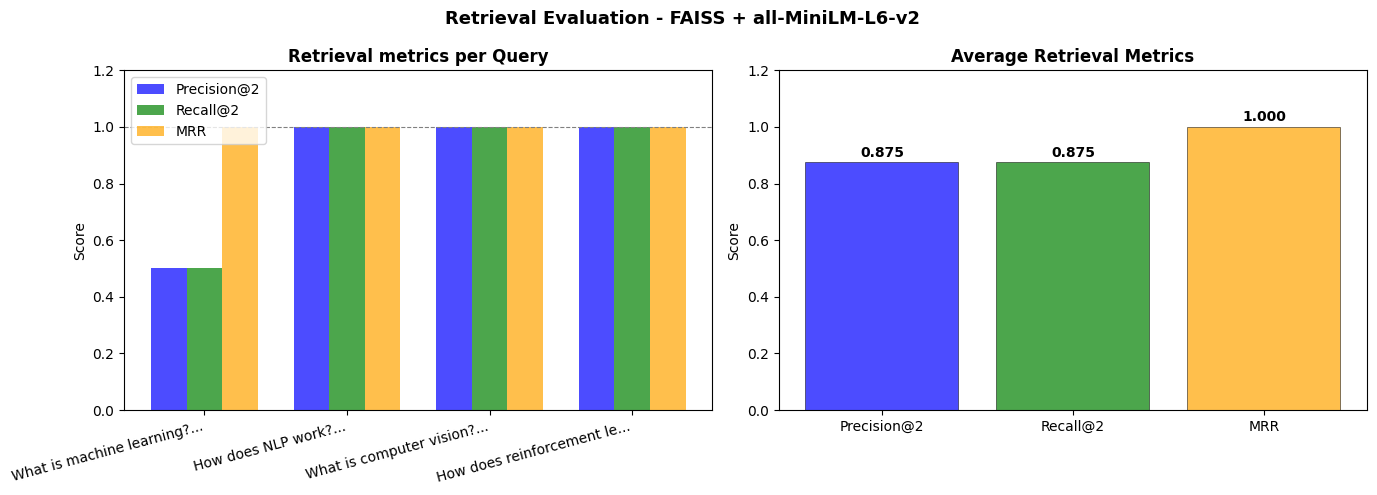

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Metrics per query
short_queries = [q[:25] + "..." for q in df["query"]]
x = np.arange(len(short_queries))
width = 0.25

axes[0].bar(x - width, df[f"precision@{K}"], width, label=f"Precision@{K}", color="blue", alpha=0.7)
axes[0].bar(x, df[f"recall@{K}"], width, label=f"Recall@{K}", color="green", alpha=0.7)
axes[0].bar(x + width, df["mrr"], width, label="MRR", color="orange", alpha=0.7)

axes[0].set_title("Retrieval metrics per Query", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_queries, rotation=15, ha="right")
axes[0].legend()
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8)

# Chart 2 - Average metrics
avg_metrics = {
    f"Precision@{K}": df[f"precision@{K}"].mean(),
    f"Recall@{K}": df[f"recall@{K}"].mean(),
    "MRR": df["mrr"].mean()
}
colors = ["blue", "green", "orange"]
bars = axes[1].bar(avg_metrics.keys(), avg_metrics.values(), color=colors, alpha=0.7, edgecolor="black", linewidth=0.5)
axes[1].set_title("Average Retrieval Metrics", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.2)
for bar, val in zip(bars, avg_metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", fontweight="bold")

plt.suptitle("Retrieval Evaluation - FAISS + all-MiniLM-L6-v2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("retrieval_evaluation.png", dpi=300)
plt.show()

## 5. Key Observations

| Metric | Score | Interpretation |
|--------|-------|----------------|
| Precision@2 | 0.875 | 87.5% of retrieved chunks are relevant |
| Recall@2 | 0.875 | 87.5% of relevant chunks are found |
| MRR | 1.000 | First result is always relevant |

## Why Machine Learning Query Scored Lower
"What is machine learning?" retrieved one irrelevant chunk.
ML and Deep Learning are semantically close — hard to distinguish.
This is a fundamental limitation of semantic retrieval.

## Key Insight
MRR = 1.0 means the most relevant chunk is always ranked first.
Even when precision is not perfect, the top result is always correct.
In production, users usually only look at the first result.

## Conclusion
FAISS + all-MiniLM-L6-v2 is a strong retrieval combination.
Precision@2: 0.875, Recall@2: 0.875, MRR: 1.0
The main failure case is semantically similar topics in the same domain.